In [ ]:
# Write a program to convert a color image to grayscale using cv2.cvtColor().

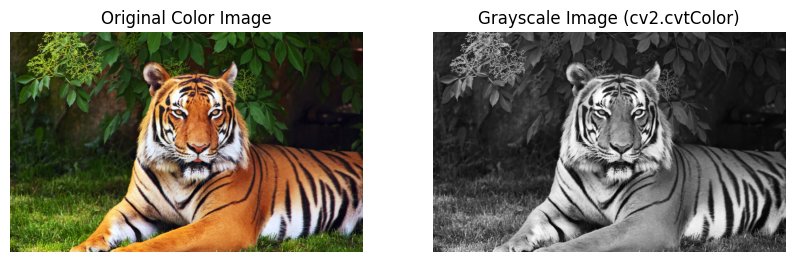

In [7]:
import cv2
import matplotlib.pyplot as plt
import os
import requests
import numpy as np

# Define the path for the color image
color_image_path = '/content/tigerr.jpg'

# Download a sample color image if it doesn't exist
if not os.path.exists(color_image_path):
    print(f"Downloading a sample color image to {color_image_path}...")
    sample_color_image_url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/Haus_zur_Liebe_mit_Regenbogen.jpg/640px-Haus_zur_Liebe_mit_Regenbogen.jpg'
    try:
        response = requests.get(sample_color_image_url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(color_image_path, 'wb') as f:
            f.write(response.content)
        print("Download complete.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
        print("Could not download a sample image. Please ensure you have internet connectivity or provide a valid image path.")
        # Create a dummy color image if download fails
        color_image = np.zeros((100, 100, 3), dtype=np.uint8)
        color_image[:, :50] = [255, 0, 0]  # Red left half
        color_image[:, 50:] = [0, 255, 0]  # Green right half
        cv2.imwrite(color_image_path, color_image)
        print("Generated a dummy color image.")

# Read the color image
color_image = cv2.imread(color_image_path)

if color_image is None:
    print(f"Error: Could not load the image from {color_image_path}. Please check the path.")
else:
    # OpenCV reads images as BGR, convert to RGB for matplotlib display
    color_image_rgb = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

    # Convert the color image to grayscale
    gray_image_converted = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

    # Display both images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(color_image_rgb)
    plt.title('Original Color Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gray_image_converted, cmap='gray')
    plt.title('Grayscale Image (cv2.cvtColor)')
    plt.axis('off')

    plt.show()

### Explanation:
1.  **Import Libraries**: We import `cv2` for image processing and `matplotlib.pyplot` for displaying images.
2.  **Load Color Image**: The code first defines a path for a sample color image. It then checks if this image exists locally. If not, it attempts to download a sample color image from a public URL to make the code runnable out-of-the-box. If the download fails, a simple dummy color image is generated.
3.  **BGR to RGB Conversion**: OpenCV reads images in BGR format. For correct display with `matplotlib`, the `color_image` is converted from BGR to RGB using `cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)`.
4.  **Color to Grayscale Conversion**: The core of the task is performed using `cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)`. This function takes the original BGR color image and converts it into a single-channel grayscale image.
5.  **Display Images**: Both the original color image (converted to RGB for correct display) and the newly generated grayscale image are displayed side-by-side using `matplotlib`.